# 05 – Dataset Builder

Dieses Notebook dokumentiert und demonstriert die fünfte Stufe des
Bitcoin-Price-Prediction-Projekts.

Voraussetzungen:

- `03_feature_engineering.ipynb` beziehungsweise `feature_engineering.py`
  haben den Feature-Datensatz erzeugt.
- `04_target_engineering.ipynb` beziehungsweise `target_engineering.py`
  haben den Target-Datensatz erzeugt.
- `dataset_builder.py` hat Feature- und Targetdaten über den eindeutigen
  Schlüssel `symbol`, `interval`, `open_time` verbunden.

Untersucht werden:

- Feature-Target-Kompatibilität,
- one-to-one-Schlüsselüberdeckung,
- nicht gematchte Zeilen,
- Master- und Task-Datensätze,
- Spaltenrollen,
- Trennung von `X`, Target und Metadaten,
- Leakage-Schutz,
- Klassenverteilungen,
- zeitliche Targetausrichtung,
- Schema- und Freigabeprüfungen.

Das Notebook erzeugt **keine zeitlichen Splits**. Diese werden erst durch
`time_series_splitter.py` und das sechste Notebook behandelt.

## 1. Umgebung und Imports

Das Notebook sucht die Projektwurzel automatisch. Es kann daher direkt
aus dem Projektordner oder aus einem Unterordner wie `notebooks/`
gestartet werden.

In [1]:
from __future__ import annotations

import gc
import json
import sys
from pathlib import Path

from IPython import get_ipython
from IPython.display import Markdown, display

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 240)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

search_locations = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    (
        path
        for path in search_locations
        if (path / "dataset_builder.py").exists()
        and (
            (path / "config.py").exists()
            or (path / "config_complete.py").exists()
        )
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Projektwurzel nicht gefunden. Starte das Notebook im "
        "Projektverzeichnis oder in einem Unterordner."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from config import SETTINGS
except ImportError:
    from config_complete import SETTINGS

from dataset_builder import (
    build_column_roles,
    build_task_dataset,
    create_task_specs,
    dataset_overview,
    infer_feature_columns,
    load_feature_dataset,
    load_target_dataset,
    merge_features_and_targets,
    run_dataset_builder,
    select_primary_target,
    validate_deterministic_merge,
    validate_modeling_dataset,
)

print(f"Projektwurzel: {PROJECT_ROOT}")
print(
    f"Symbol / Intervall: "
    f"{SETTINGS.market.symbol} / {SETTINGS.market.interval}"
)
print(f"Pandas: {pd.__version__}")
print(f"PyArrow: {pa.__version__}")

Projektwurzel: /home/milan/uni/python/BTC TSP/BTC TSP 15min
Symbol / Intervall: BTCUSDT / 15m
Pandas: 3.0.3
PyArrow: 24.0.0


## 2. Parameter und Pfade

In [2]:
# Der produktive Builder wurde bereits ausgeführt. Ein vollständiger
# Neuaufbau ist daher standardmäßig deaktiviert.
REBUILD_DATASETS = False

# Vollständige Determinismusprüfung kann je nach Datensatzgröße länger
# dauern. Im Notebook wird ansonsten eine Schlüsselstichprobe geprüft.
RUN_FULL_DETERMINISM_CHECK = False

# Anzahl ausgewählter Modellfeatures für visuelle Stichproben.
MAXIMUM_SAMPLE_FEATURES = 12
RECENT_SAMPLE_ROWS = 5_000
MINIMUM_OVERLAP_RATIO = 0.95

symbol = str(SETTINGS.market.symbol)
interval = str(SETTINGS.market.interval)

feature_path = (
    Path(SETTINGS.paths.features_dir)
    / f"{symbol}_{interval}_features.parquet"
)

processed_dir = Path(SETTINGS.paths.processed_dir)
target_path = (
    getattr(SETTINGS.paths, "targets_dir", None)
    or processed_dir / "targets"
)
target_path = Path(target_path) / f"{symbol}_{interval}_targets.parquet"

datasets_dir = Path(SETTINGS.paths.datasets_dir)
master_path = datasets_dir / f"{symbol}_{interval}_master_dataset.parquet"

display(
    pd.DataFrame(
        [
            {
                "artifact": "features",
                "path": str(feature_path),
                "exists": feature_path.exists(),
            },
            {
                "artifact": "targets",
                "path": str(target_path),
                "exists": target_path.exists(),
            },
            {
                "artifact": "master",
                "path": str(master_path),
                "exists": master_path.exists(),
            },
        ]
    )
)

for required_path in (feature_path, target_path):
    if not required_path.exists():
        raise FileNotFoundError(f"Erforderliche Datei fehlt: {required_path}")

,artifact,path,exists
0,features,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,True
1,targets,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,True
2,master,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,True


## 3. Optionaler vollständiger Builder-Lauf

Der vollständige Lauf verwendet den speicherschonenden produktiven
Builder. Er sollte nur aktiviert werden, wenn Feature- oder Targetdaten
seit dem letzten Lauf verändert wurden.

In [3]:
if REBUILD_DATASETS:
    builder_result = run_dataset_builder(
        SETTINGS,
        feature_path=feature_path,
        target_path=target_path,
        minimum_overlap_ratio=MINIMUM_OVERLAP_RATIO,
        verify_deterministic=RUN_FULL_DETERMINISM_CHECK,
    )
    display(pd.DataFrame([builder_result.to_dict()]))
else:
    print(
        "Vollständiger Neuaufbau übersprungen. "
        "Vorhandene Builder-Ausgaben werden analysiert."
    )

Vollständiger Neuaufbau übersprungen. Vorhandene Builder-Ausgaben werden analysiert.


## 4. Parquet-Metadaten und Schemas

In [4]:
def parquet_record(path: Path) -> dict[str, object]:
    parquet_file = pq.ParquetFile(path)
    return {
        "file": path.name,
        "rows": parquet_file.metadata.num_rows,
        "columns": len(parquet_file.schema_arrow.names),
        "row_groups": parquet_file.metadata.num_row_groups,
        "size_mib": path.stat().st_size / 2**20,
    }


input_records = [
    parquet_record(feature_path),
    parquet_record(target_path),
]

if master_path.exists():
    input_records.append(parquet_record(master_path))

display(pd.DataFrame(input_records))

feature_schema = pq.ParquetFile(feature_path).schema_arrow
target_schema = pq.ParquetFile(target_path).schema_arrow

feature_schema_frame = pd.DataFrame(
    {
        "column": feature_schema.names,
        "dtype": [str(field.type) for field in feature_schema],
    }
)
target_schema_frame = pd.DataFrame(
    {
        "column": target_schema.names,
        "dtype": [str(field.type) for field in target_schema],
    }
)

print("Feature-Schema:")
display(feature_schema_frame.head(30))
print("Target-Schema:")
display(target_schema_frame)

,file,rows,columns,row_groups,size_mib
0,BTCUSDT_15m_features.parquet,229434,350,1,554.818384
1,BTCUSDT_15m_targets.parquet,228570,47,1,64.037024
2,BTCUSDT_15m_master_dataset.parquet,227898,394,1,613.895563


Feature-Schema:


,column,dtype
0,symbol,large_string
1,interval,large_string
2,open_time,"timestamp[us, tz=UTC]"
3,close_time,"timestamp[us, tz=UTC]"
4,source,large_string
5,ingested_at,"timestamp[us, tz=UTC]"
6,open,double
7,high,double
8,low,double
9,close,double


Target-Schema:


,column,dtype
0,symbol,large_string
1,interval,large_string
2,open_time,"timestamp[us, tz=UTC]"
3,target_end_time_1,"timestamp[us, tz=UTC]"
4,target_return_1,double
5,target_return_log_1,double
6,target_return_simple_1,double
7,target_binary_1,int8
8,target_multiclass_1,int8
9,target_future_max_return_1,double


## 5. Modellfeatures und Targetspalten

Rohpreise, Volumen-Marktspalten und technische Metadaten gehören nicht
automatisch zur späteren Featurematrix `X`. Der Dataset Builder übernimmt
ausschließlich die von `feature_engineering.py` erzeugten Modellfeatures.

In [5]:
# Ein leerer Frame mit dem realen Spaltenschema genügt zur
# rollenkonsistenten Ermittlung der Featureliste.
empty_feature_frame = pd.DataFrame(columns=feature_schema.names)
feature_columns = infer_feature_columns(empty_feature_frame)

target_end_time_columns = [
    column
    for column in target_schema.names
    if column.startswith("target_end_time_")
]
target_value_columns = [
    column
    for column in target_schema.names
    if column.startswith("target_")
    and column not in target_end_time_columns
]

primary_target = select_primary_target(SETTINGS)

display(
    pd.DataFrame(
        [
            {
                "Modellfeatures": len(feature_columns),
                "Target-Endzeitspalten": len(target_end_time_columns),
                "Targetwertspalten": len(target_value_columns),
                "Primärtarget": primary_target,
            }
        ]
    )
)

display(pd.DataFrame({"feature": feature_columns}).head(40))
display(pd.DataFrame({"target": target_value_columns}))

,Modellfeatures,Target-Endzeitspalten,Targetwertspalten,Primärtarget
0,335,4,40,target_binary_4


,feature
0,return_simple_1
1,return_log_1
2,momentum_absolute_1
3,momentum_relative_1
4,return_simple_2
5,return_log_2
6,momentum_absolute_2
7,momentum_relative_2
8,return_simple_4
9,return_log_4


,target
0,target_return_1
1,target_return_log_1
2,target_return_simple_1
3,target_binary_1
4,target_multiclass_1
5,target_future_max_return_1
6,target_future_min_return_1
7,target_future_realized_volatility_1
8,target_future_realized_volatility_annualized_1
9,target_future_max_drawdown_1


## 6. Speicherschonende Schlüsselüberdeckung

Für die Merge-Diagnostik werden nur die drei Schlüsselspalten geladen.
Der breite Featureblock bleibt dabei außerhalb des Arbeitsspeichers.

In [6]:
key_columns = ["symbol", "interval", "open_time"]

feature_keys = pd.read_parquet(
    feature_path,
    columns=key_columns,
)
target_keys = pd.read_parquet(
    target_path,
    columns=key_columns,
)

for frame in (feature_keys, target_keys):
    frame["symbol"] = frame["symbol"].astype("string")
    frame["interval"] = frame["interval"].astype("string")
    frame["open_time"] = pd.to_datetime(
        frame["open_time"],
        utc=True,
        errors="raise",
    )

key_diagnostics = feature_keys.merge(
    target_keys,
    on=key_columns,
    how="outer",
    indicator=True,
    validate="one_to_one",
)

merge_counts = (
    key_diagnostics["_merge"]
    .value_counts()
    .rename_axis("merge_state")
    .reset_index(name="rows")
)
merge_counts["ratio"] = merge_counts["rows"] / len(key_diagnostics)

matched_rows = int((key_diagnostics["_merge"] == "both").sum())
overlap_ratio = matched_rows / min(len(feature_keys), len(target_keys))

display(merge_counts)
display(
    pd.DataFrame(
        [
            {
                "feature_rows": len(feature_keys),
                "target_rows": len(target_keys),
                "matched_rows": matched_rows,
                "feature_only_rows": int(
                    (key_diagnostics["_merge"] == "left_only").sum()
                ),
                "target_only_rows": int(
                    (key_diagnostics["_merge"] == "right_only").sum()
                ),
                "overlap_ratio_of_smaller": overlap_ratio,
                "minimum_required": MINIMUM_OVERLAP_RATIO,
            }
        ]
    )
)

assert overlap_ratio >= MINIMUM_OVERLAP_RATIO

,merge_state,rows,ratio
0,both,227898,0.990404
1,left_only,1536,0.006675
2,right_only,672,0.002920


,feature_rows,target_rows,matched_rows,feature_only_rows,target_only_rows,overlap_ratio_of_smaller,minimum_required
0,229434,228570,227898,1536,672,0.997060,0.950000


## 7. Warum nicht alle Zeilen gematcht werden

Zwei erwartete Effekte führen zu Randverlusten:

1. Der Feature-Datensatz beginnt später, weil Rolling Features eine
   Warm-up-Historie benötigen.
2. Der Target-Datensatz endet früher, weil am Datensatzende keine
   vollständigen Zukunftshorizonte mehr vorhanden sind.

Datenlücken können zusätzlich lokale Targetfenster ungültig machen.

/tmp/ipykernel_32735/3799037233.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  unmatched["month"] = unmatched["open_time"].dt.to_period("M").astype(str)


,symbol,interval,open_time,_merge,year,month
0,BTCUSDT,15m,2020-01-01 00:00:00+00:00,right_only,2020,2020-01
1,BTCUSDT,15m,2020-01-01 00:15:00+00:00,right_only,2020,2020-01
2,BTCUSDT,15m,2020-01-01 00:30:00+00:00,right_only,2020,2020-01
3,BTCUSDT,15m,2020-01-01 00:45:00+00:00,right_only,2020,2020-01
4,BTCUSDT,15m,2020-01-01 01:00:00+00:00,right_only,2020,2020-01
5,BTCUSDT,15m,2020-01-01 01:15:00+00:00,right_only,2020,2020-01
6,BTCUSDT,15m,2020-01-01 01:30:00+00:00,right_only,2020,2020-01
7,BTCUSDT,15m,2020-01-01 01:45:00+00:00,right_only,2020,2020-01
8,BTCUSDT,15m,2020-01-01 02:00:00+00:00,right_only,2020,2020-01
9,BTCUSDT,15m,2020-01-01 02:15:00+00:00,right_only,2020,2020-01


,year,_merge,rows
0,2020,left_only,768
1,2020,right_only,672
2,2021,left_only,576
3,2023,left_only,96
4,2026,left_only,96


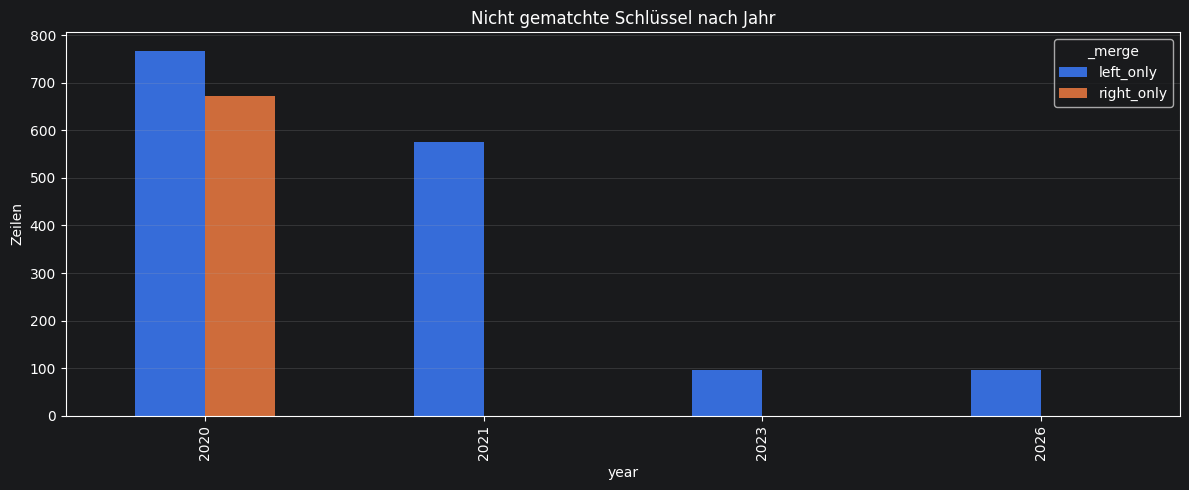

In [7]:
unmatched = key_diagnostics.loc[
    key_diagnostics["_merge"] != "both"
].copy()
unmatched["year"] = unmatched["open_time"].dt.year
unmatched["month"] = unmatched["open_time"].dt.to_period("M").astype(str)

unmatched_by_year = (
    unmatched
    .groupby(["year", "_merge"], observed=True)
    .size()
    .rename("rows")
    .reset_index()
)

display(unmatched.head(20))
display(unmatched_by_year)

if not unmatched.empty:
    pivot = (
        unmatched_by_year
        .pivot(index="year", columns="_merge", values="rows")
        .fillna(0)
    )

    figure, axis = plt.subplots(figsize=(12, 5))
    pivot.plot(kind="bar", ax=axis)
    axis.set_title("Nicht gematchte Schlüssel nach Jahr")
    axis.set_ylabel("Zeilen")
    axis.grid(True, axis="y", alpha=0.25)
    figure.tight_layout()
    display(figure)
    plt.close(figure)

## 8. Zeitliche Abdeckung der Eingaben

In [8]:
coverage = pd.DataFrame(
    [
        {
            "dataset": "features",
            "rows": len(feature_keys),
            "first_open_time": feature_keys["open_time"].min(),
            "last_open_time": feature_keys["open_time"].max(),
        },
        {
            "dataset": "targets",
            "rows": len(target_keys),
            "first_open_time": target_keys["open_time"].min(),
            "last_open_time": target_keys["open_time"].max(),
        },
        {
            "dataset": "matched",
            "rows": matched_rows,
            "first_open_time": key_diagnostics.loc[
                key_diagnostics["_merge"] == "both", "open_time"
            ].min(),
            "last_open_time": key_diagnostics.loc[
                key_diagnostics["_merge"] == "both", "open_time"
            ].max(),
        },
    ]
)

display(coverage)

,dataset,rows,first_open_time,last_open_time
0,features,229434,2020-01-08 00:00:00+00:00,2026-07-26 12:15:00+00:00
1,targets,228570,2020-01-01 00:00:00+00:00,2026-07-25 12:15:00+00:00
2,matched,227898,2020-01-08 00:00:00+00:00,2026-07-25 12:15:00+00:00


## 9. Deterministischer one-to-one-Merge auf einer Stichprobe

Die Stichprobe ist gleichmäßig über die gemeinsame Zeitachse verteilt.
Dadurch wird der Merge geprüft, ohne mehrere vollständige Kopien des
breiten Datensatzes zu erzeugen.

In [9]:
common_keys = key_diagnostics.loc[
    key_diagnostics["_merge"] == "both",
    key_columns,
].sort_values("open_time").reset_index(drop=True)

sample_size = min(4_096, len(common_keys))
sample_positions = np.linspace(
    0,
    len(common_keys) - 1,
    sample_size,
    dtype=int,
)
sampled_keys = common_keys.iloc[sample_positions].copy()

sampled_feature_keys = sampled_keys.merge(
    feature_keys,
    on=key_columns,
    how="left",
    validate="one_to_one",
)
sampled_target_keys = sampled_keys.merge(
    target_keys,
    on=key_columns,
    how="left",
    validate="one_to_one",
)

merge_a = sampled_feature_keys.merge(
    sampled_target_keys,
    on=key_columns,
    how="inner",
    validate="one_to_one",
)
merge_b = sampled_feature_keys.merge(
    sampled_target_keys,
    on=key_columns,
    how="inner",
    validate="one_to_one",
)

pd.testing.assert_frame_equal(
    merge_a,
    merge_b,
    check_exact=True,
)

display(
    pd.DataFrame(
        [
            {
                "sample_rows": len(sampled_keys),
                "first_open_time": sampled_keys["open_time"].min(),
                "last_open_time": sampled_keys["open_time"].max(),
                "deterministic": True,
            }
        ]
    )
)

,sample_rows,first_open_time,last_open_time,deterministic
0,4096,2020-01-08 00:00:00+00:00,2026-07-25 12:15:00+00:00,True


## 10. Master-Datensatz

Der Master-Datensatz enthält alle Feature-, Markt-, Metadaten- und
Targetspalten. Er ist ein dokumentierter Zwischenstand, aber nicht direkt
die Featurematrix für ein Modell.

In [10]:
if not master_path.exists():
    raise FileNotFoundError(
        f"Master-Datensatz fehlt: {master_path}. "
        "Führe zuerst python dataset_builder.py aus."
    )

master_parquet = pq.ParquetFile(master_path)
master_schema = master_parquet.schema_arrow

master_summary = pd.DataFrame(
    [
        {
            "rows": master_parquet.metadata.num_rows,
            "columns": len(master_schema.names),
            "row_groups": master_parquet.metadata.num_row_groups,
            "size_mib": master_path.stat().st_size / 2**20,
            "contains_primary_target": primary_target in master_schema.names,
        }
    ]
)
display(master_summary)

expected_master_rows = matched_rows
actual_master_rows = master_parquet.metadata.num_rows

assert actual_master_rows == expected_master_rows, (
    f"Master enthält {actual_master_rows:,} statt "
    f"{expected_master_rows:,} erwarteter Zeilen."
)

,rows,columns,row_groups,size_mib,contains_primary_target
0,227898,394,1,613.895563,True


## 11. Spaltenrollen im Master-Datensatz

In [11]:
# build_column_roles benötigt nur Spaltennamen und Dtypes. Ein leerer
# Schema-Frame verhindert das Laden des breiten Master-Datensatzes.
empty_master = pd.DataFrame(
    {
        field.name: pd.Series(dtype="object")
        for field in master_schema
    }
)

task_specs = create_task_specs(
    SETTINGS,
    master_schema.names,
)

column_roles = build_column_roles(
    empty_master,
    feature_columns,
    SETTINGS,
    task_specs,
)

role_summary = (
    column_roles
    .groupby("role", observed=True)
    .agg(
        columns=("column", "count"),
        included_in_X=("included_in_X", "sum"),
    )
    .reset_index()
    .sort_values("columns", ascending=False)
)

display(role_summary)
display(column_roles.head(50))

assert not (column_roles["role"] == "unclassified").any()
assert int(column_roles["included_in_X"].sum()) == len(feature_columns)

,role,columns,included_in_X
0,feature,335,335
4,target,40,0
3,market_context,9,0
5,target_end_time,4,0
1,feature_metadata,3,0
2,identifier,3,0


,position,column,dtype,role,included_in_X,included_in_master,included_in_task_datasets,is_primary_target
0,0,symbol,object,identifier,False,True,,False
1,1,interval,object,identifier,False,True,,False
2,2,open_time,object,identifier,False,True,,False
3,3,close_time,object,feature_metadata,False,True,,False
4,4,source,object,feature_metadata,False,True,,False
5,5,ingested_at,object,feature_metadata,False,True,,False
6,6,open,object,market_context,False,True,,False
7,7,high,object,market_context,False,True,,False
8,8,low,object,market_context,False,True,,False
9,9,close,object,market_context,False,True,,False


## 12. Aufgabenspezifische Datensatzdefinitionen

In [12]:
task_spec_frame = pd.DataFrame(
    [spec.to_dict() for spec in task_specs]
)
display(task_spec_frame)

for spec in task_specs:
    if not spec.output_path.exists():
        raise FileNotFoundError(
            f"Task-Datensatz fehlt: {spec.output_path}"
        )

,task,horizon,target_column,end_time_column,dataset_name,output_path,is_primary
0,regression,4,target_return_4,target_end_time_4,regression_h4,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,False
1,binary_classification,4,target_binary_4,target_end_time_4,binary_h4,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,True
2,multiclass_classification,4,target_multiclass_4,target_end_time_4,multiclass_h4,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,False
3,volatility_regression,16,target_future_realized_volatility_annualized_16,target_end_time_16,volatility_h16,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,False


## 13. Task-Schemas und Leakage-Schutz

Ein Task-Datensatz darf ausschließlich enthalten:

```text
symbol
interval
open_time
+ Modellfeatures
+ genau eine Target-Endzeit
+ genau ein Werttarget
```

In [13]:
task_schema_rows = []
leakage_rows = []

for spec in task_specs:
    schema = pq.ParquetFile(spec.output_path).schema_arrow
    columns = schema.names

    target_columns_in_file = [
        column
        for column in columns
        if column.startswith("target_")
        and not column.startswith("target_end_time_")
    ]
    end_time_columns_in_file = [
        column
        for column in columns
        if column.startswith("target_end_time_")
    ]
    task_feature_columns = [
        column
        for column in columns
        if column not in {
            "symbol",
            "interval",
            "open_time",
            spec.target_column,
            spec.end_time_column,
        }
    ]

    leakage_features = [
        column
        for column in task_feature_columns
        if any(
            fragment in column.lower()
            for fragment in (
                "target",
                "future",
                "label",
                "prediction",
                "y_true",
            )
        )
    ]

    task_schema_rows.append(
        {
            "dataset": spec.dataset_name,
            "task": spec.task,
            "horizon": spec.horizon,
            "rows": pq.ParquetFile(spec.output_path).metadata.num_rows,
            "columns": len(columns),
            "features": len(task_feature_columns),
            "value_targets": len(target_columns_in_file),
            "end_time_columns": len(end_time_columns_in_file),
            "target": spec.target_column,
            "is_primary": spec.is_primary,
        }
    )

    leakage_rows.append(
        {
            "dataset": spec.dataset_name,
            "unexpected_targets": sorted(
                set(target_columns_in_file) - {spec.target_column}
            ),
            "unexpected_end_times": sorted(
                set(end_time_columns_in_file) - {spec.end_time_column}
            ),
            "leakage_features": leakage_features,
            "passed": (
                target_columns_in_file == [spec.target_column]
                and end_time_columns_in_file == [spec.end_time_column]
                and not leakage_features
            ),
        }
    )

task_schema_frame = pd.DataFrame(task_schema_rows)
leakage_frame = pd.DataFrame(leakage_rows)

display(task_schema_frame)
display(leakage_frame)

assert leakage_frame["passed"].all()

,dataset,task,horizon,rows,columns,features,value_targets,end_time_columns,target,is_primary
0,regression_h4,regression,4,227898,340,335,1,1,target_return_4,False
1,binary_h4,binary_classification,4,227898,340,335,1,1,target_binary_4,True
2,multiclass_h4,multiclass_classification,4,227898,340,335,1,1,target_multiclass_4,False
3,volatility_h16,volatility_regression,16,227898,340,335,1,1,target_future_realized_volatility_annualized_16,False


,dataset,unexpected_targets,unexpected_end_times,leakage_features,passed
0,regression_h4,[],[],[],True
1,binary_h4,[],[],[],True
2,multiclass_h4,[],[],[],True
3,volatility_h16,[],[],[],True


## 14. Primärer Task-Datensatz

In [14]:
primary_spec = next(spec for spec in task_specs if spec.is_primary)
primary_path = primary_spec.output_path
primary_parquet = pq.ParquetFile(primary_path)
primary_schema = primary_parquet.schema_arrow

primary_metadata = pd.read_parquet(
    primary_path,
    columns=[
        "symbol",
        "interval",
        "open_time",
        primary_spec.end_time_column,
        primary_spec.target_column,
    ],
)

primary_metadata["open_time"] = pd.to_datetime(
    primary_metadata["open_time"],
    utc=True,
)
primary_metadata[primary_spec.end_time_column] = pd.to_datetime(
    primary_metadata[primary_spec.end_time_column],
    utc=True,
)

display(
    pd.DataFrame(
        [
            {
                "dataset": primary_spec.dataset_name,
                "task": primary_spec.task,
                "horizon": primary_spec.horizon,
                "target": primary_spec.target_column,
                "rows": len(primary_metadata),
                "feature_count": (
                    len(primary_schema.names) - 5
                ),
                "first_open_time": primary_metadata["open_time"].min(),
                "last_open_time": primary_metadata["open_time"].max(),
            }
        ]
    )
)

display(primary_metadata.head(5))
display(primary_metadata.tail(5))

,dataset,task,horizon,target,rows,feature_count,first_open_time,last_open_time
0,binary_h4,binary_classification,4,target_binary_4,227898,335,2020-01-08 00:00:00+00:00,2026-07-25 12:15:00+00:00


,symbol,interval,open_time,target_end_time_4,target_binary_4
0,BTCUSDT,15m,2020-01-08 00:00:00+00:00,2020-01-08 01:00:00+00:00,1
1,BTCUSDT,15m,2020-01-08 00:15:00+00:00,2020-01-08 01:15:00+00:00,1
2,BTCUSDT,15m,2020-01-08 00:30:00+00:00,2020-01-08 01:30:00+00:00,1
3,BTCUSDT,15m,2020-01-08 00:45:00+00:00,2020-01-08 01:45:00+00:00,0
4,BTCUSDT,15m,2020-01-08 01:00:00+00:00,2020-01-08 02:00:00+00:00,0


,symbol,interval,open_time,target_end_time_4,target_binary_4
227893,BTCUSDT,15m,2026-07-25 11:15:00+00:00,2026-07-25 12:15:00+00:00,0
227894,BTCUSDT,15m,2026-07-25 11:30:00+00:00,2026-07-25 12:30:00+00:00,0
227895,BTCUSDT,15m,2026-07-25 11:45:00+00:00,2026-07-25 12:45:00+00:00,0
227896,BTCUSDT,15m,2026-07-25 12:00:00+00:00,2026-07-25 13:00:00+00:00,1
227897,BTCUSDT,15m,2026-07-25 12:15:00+00:00,2026-07-25 13:15:00+00:00,1


## 15. Exakte zeitliche Targetausrichtung

In [15]:
expected_target_end = (
    primary_metadata["open_time"]
    + pd.Timedelta(minutes=int(SETTINGS.market.interval_minutes))
    * int(primary_spec.horizon)
)

alignment_mismatches = int(
    (
        primary_metadata[primary_spec.end_time_column]
        != expected_target_end
    ).sum()
)

display(
    pd.DataFrame(
        [
            {
                "horizon_candles": primary_spec.horizon,
                "horizon_duration": (
                    pd.Timedelta(
                        minutes=int(SETTINGS.market.interval_minutes)
                    )
                    * int(primary_spec.horizon)
                ),
                "alignment_mismatches": alignment_mismatches,
                "passed": alignment_mismatches == 0,
            }
        ]
    )
)

assert alignment_mismatches == 0

,horizon_candles,horizon_duration,alignment_mismatches,passed
0,4,0 days 01:00:00,0,True


## 16. Klassen- beziehungsweise Targetverteilung

,class,count,ratio
0,0,140591,0.616903
1,1,87307,0.383097


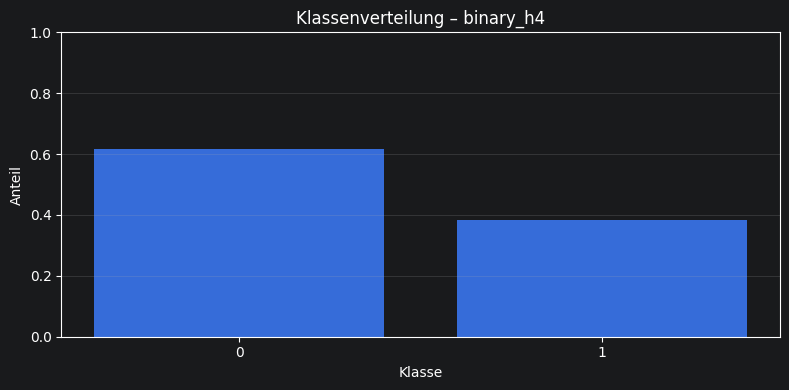

In [16]:
target_series = pd.to_numeric(
    primary_metadata[primary_spec.target_column],
    errors="raise",
)

if primary_spec.task in {
    "binary_classification",
    "multiclass_classification",
}:
    class_balance = (
        target_series
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("class")
        .reset_index(name="count")
    )
    class_balance["ratio"] = class_balance["count"] / len(target_series)
    display(class_balance)

    figure, axis = plt.subplots(figsize=(8, 4))
    axis.bar(
        class_balance["class"].astype(str),
        class_balance["ratio"],
    )
    axis.set_title(
        f"Klassenverteilung – {primary_spec.dataset_name}"
    )
    axis.set_xlabel("Klasse")
    axis.set_ylabel("Anteil")
    axis.set_ylim(0, 1)
    axis.grid(True, axis="y", alpha=0.25)
    figure.tight_layout()
    display(figure)
    plt.close(figure)
else:
    display(
        target_series.describe(
            percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
        ).to_frame("value")
    )

    figure, axis = plt.subplots(figsize=(10, 4))
    axis.hist(target_series, bins=100)
    axis.set_title(
        f"Targetverteilung – {primary_spec.dataset_name}"
    )
    axis.grid(True, alpha=0.25)
    figure.tight_layout()
    display(figure)
    plt.close(figure)

## 17. Zeitliche Stabilität des Primärtargets

,year,target_binary_4,ratio
0,2020,0,0.603171
1,2020,1,0.396829
2,2021,0,0.559755
3,2021,1,0.440245
4,2022,0,0.614355
5,2022,1,0.385645
6,2023,0,0.665789
7,2023,1,0.334211
8,2024,0,0.608322
9,2024,1,0.391678


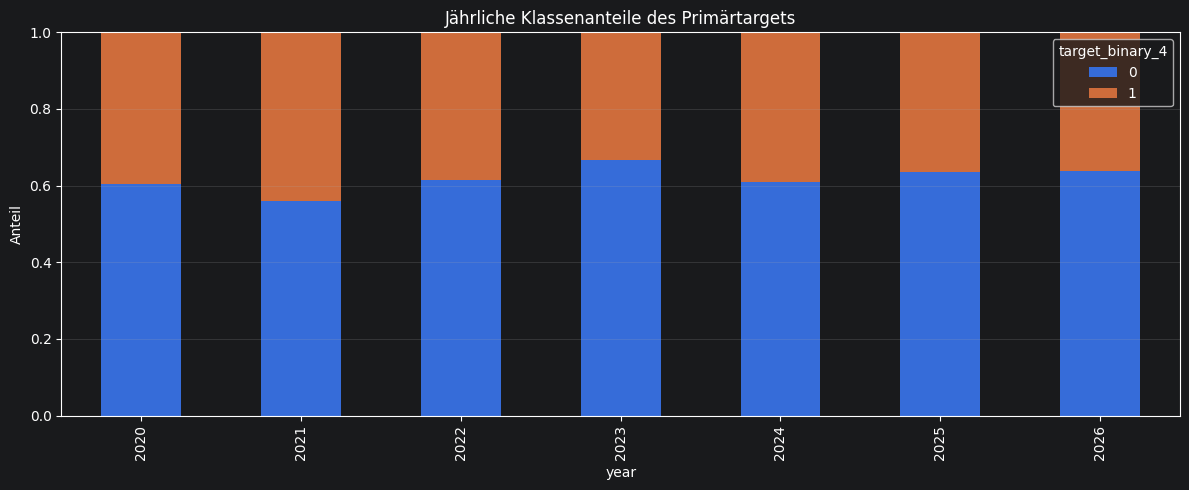

In [17]:
target_stability = primary_metadata[
    ["open_time", primary_spec.target_column]
].copy()
target_stability["year"] = target_stability["open_time"].dt.year

if primary_spec.task in {
    "binary_classification",
    "multiclass_classification",
}:
    yearly_target = (
        target_stability
        .groupby("year", observed=True)[primary_spec.target_column]
        .value_counts(normalize=True)
        .rename("ratio")
        .reset_index()
    )
    display(yearly_target)

    pivot = yearly_target.pivot(
        index="year",
        columns=primary_spec.target_column,
        values="ratio",
    ).fillna(0)

    figure, axis = plt.subplots(figsize=(12, 5))
    pivot.plot(kind="bar", stacked=True, ax=axis)
    axis.set_title("Jährliche Klassenanteile des Primärtargets")
    axis.set_ylabel("Anteil")
    axis.set_ylim(0, 1)
    axis.grid(True, axis="y", alpha=0.25)
    figure.tight_layout()
    display(figure)
    plt.close(figure)
else:
    yearly_target = (
        target_stability
        .groupby("year", observed=True)[primary_spec.target_column]
        .agg(["mean", "std", "median", "min", "max"])
        .reset_index()
    )
    display(yearly_target)

## 18. Ausgewählte Featurestichprobe

Für eine visuelle Plausibilitätsprüfung werden nur wenige Spalten und die
jüngsten Zeilen geladen. Das vollständige breite Task-Dataset bleibt
außerhalb des RAM.

In [18]:
preferred_features = [
    "return_log_1",
    "return_log_4",
    "rsi_14",
    "macd_histogram_relative",
    "volatility_historical_16",
    "volatility_historical_96",
    "volume_zscore_96",
    "trade_count_zscore_96",
    "taker_imbalance",
    "regime_trend_code",
    "regime_volatility_code",
    "calendar_hour_sin",
]

available_primary_features = [
    column
    for column in primary_schema.names
    if column not in {
        "symbol",
        "interval",
        "open_time",
        primary_spec.end_time_column,
        primary_spec.target_column,
    }
]

sample_features = [
    column
    for column in preferred_features
    if column in available_primary_features
][:MAXIMUM_SAMPLE_FEATURES]

if len(sample_features) < min(5, MAXIMUM_SAMPLE_FEATURES):
    additional = [
        column
        for column in available_primary_features
        if column not in sample_features
    ]
    sample_features.extend(
        additional[: MAXIMUM_SAMPLE_FEATURES - len(sample_features)]
    )

sample_columns = [
    "open_time",
    *sample_features,
    primary_spec.target_column,
]

sample_frame = pd.read_parquet(
    primary_path,
    columns=sample_columns,
).tail(RECENT_SAMPLE_ROWS).reset_index(drop=True)

sample_frame["open_time"] = pd.to_datetime(
    sample_frame["open_time"],
    utc=True,
)

display(sample_frame.head())
display(sample_frame[sample_features].describe().T)

,open_time,return_log_1,return_log_4,rsi_14,macd_histogram_relative,volatility_historical_16,volatility_historical_96,volume_zscore_96,trade_count_zscore_96,taker_imbalance,regime_trend_code,regime_volatility_code,calendar_hour_sin,target_binary_4
0,2026-06-03 10:30:00+00:00,-0.001246,0.007475,55.511017,0.000253,0.440393,0.673965,-0.905688,-0.833788,-0.066538,-1,0,0.500000,0
1,2026-06-03 10:45:00+00:00,0.000898,0.003265,56.912512,0.000320,0.367790,0.672069,-1.063487,-1.304891,-0.013477,-1,0,0.500000,0
2,2026-06-03 11:00:00+00:00,0.000698,0.000527,58.020794,0.000381,0.364834,0.672042,-0.953833,-1.094112,0.082865,-1,0,0.258819,0
3,2026-06-03 11:15:00+00:00,-0.000171,0.000178,57.629690,0.000380,0.357062,0.671988,-0.955110,-1.250489,0.079173,-1,-1,0.258819,0
4,2026-06-03 11:30:00+00:00,-0.002677,-0.001252,51.754593,0.000179,0.380251,0.673482,-0.978087,-1.174814,-0.067167,-1,0,0.258819,0


,count,mean,std,min,25%,50%,75%,max
return_log_1,"5,000.000000",-0.000010,0.002393,-0.030210,-0.001074,-0.000030,0.001016,0.028855
return_log_4,"5,000.000000",-0.000037,0.004705,-0.049433,-0.002157,-0.000000,0.002030,0.026009
rsi_14,"5,000.000000",50.103839,11.191846,11.290885,42.901173,50.112264,57.453158,86.379610
macd_histogram_relative,"5,000.000000",-0.000002,0.000781,-0.004605,-0.000418,-0.000022,0.000356,0.004162
volatility_historical_16,"5,000.000000",0.384785,0.233881,0.059888,0.235821,0.325709,0.447854,1.993147
volatility_historical_96,"5,000.000000",0.415602,0.180855,0.145777,0.291765,0.374287,0.471888,1.002114
volume_zscore_96,"5,000.000000",-0.006020,1.058514,-1.358067,-0.617688,-0.319534,0.220918,9.226820
trade_count_zscore_96,"5,000.000000",0.002062,1.092210,-1.701921,-0.686161,-0.322320,0.314563,8.075014
taker_imbalance,"5,000.000000",-0.023067,0.246026,-0.824312,-0.191879,-0.023889,0.148326,0.825845
regime_trend_code,"5,000.000000",-0.008200,0.819919,-1.000000,-1.000000,0.000000,1.000000,1.000000


## 19. Featurekorrelationen ohne Target-Leakage

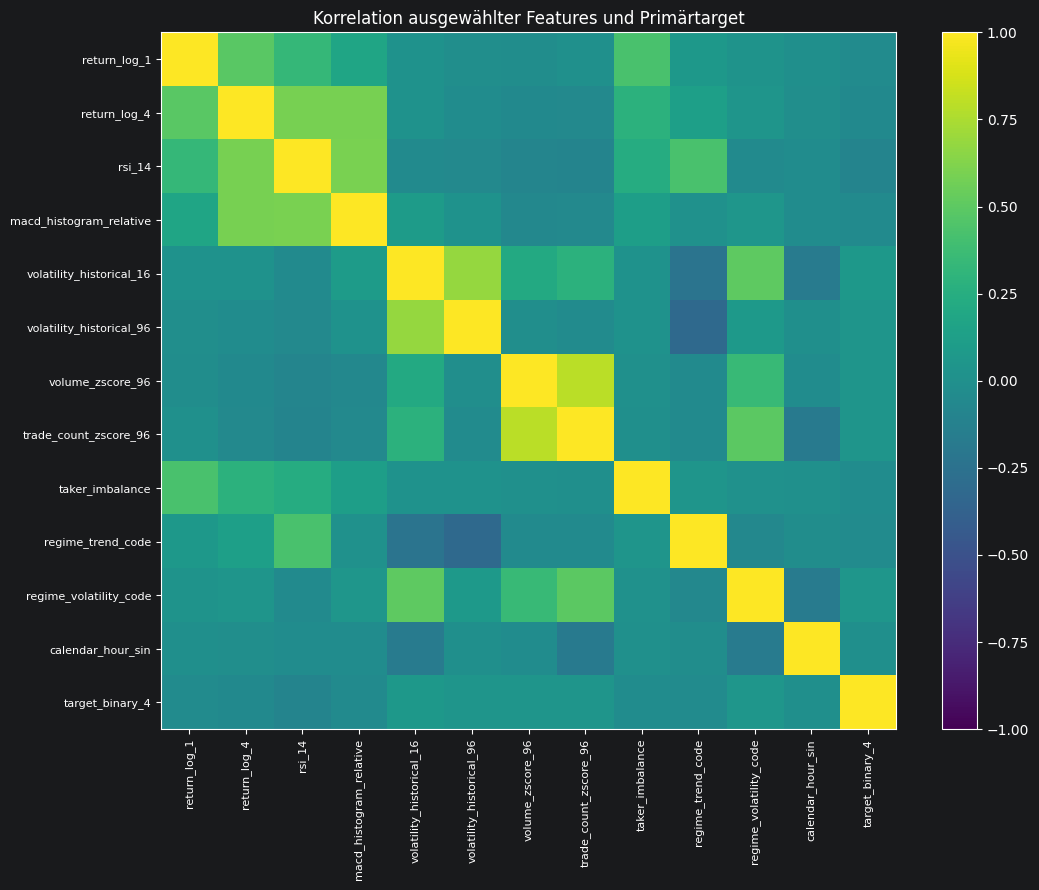

,feature,correlation
0,rsi_14,-0.097047
1,volatility_historical_16,0.064741
2,regime_volatility_code,0.053212
3,return_log_4,-0.050312
4,volatility_historical_96,0.044060
5,macd_histogram_relative,-0.042575
6,volume_zscore_96,0.041132
7,trade_count_zscore_96,0.039472
8,regime_trend_code,-0.032480
9,return_log_1,-0.032052


In [19]:
if sample_features:
    correlation_columns = [
        *sample_features,
        primary_spec.target_column,
    ]
    correlation = sample_frame[correlation_columns].corr()

    figure, axis = plt.subplots(figsize=(11, 9))
    image = axis.imshow(
        correlation.to_numpy(),
        aspect="auto",
        vmin=-1,
        vmax=1,
    )
    axis.set_xticks(range(len(correlation_columns)))
    axis.set_xticklabels(
        correlation_columns,
        rotation=90,
        fontsize=8,
    )
    axis.set_yticks(range(len(correlation_columns)))
    axis.set_yticklabels(correlation_columns, fontsize=8)
    axis.set_title("Korrelation ausgewählter Features und Primärtarget")
    figure.colorbar(image, ax=axis)
    figure.tight_layout()
    display(figure)
    plt.close(figure)

    target_correlations = (
    correlation[primary_spec.target_column]
    .drop(primary_spec.target_column)
    .sort_values(
        key=lambda series: series.abs(),
        ascending=False,
    )
    .rename_axis("feature")
    .reset_index(name="correlation")
    )
    display(target_correlations)

## 20. Builder-Berichte und Manifest

In [20]:
reports_root = Path(SETTINGS.paths.reports_dir) / "dataset_builder"
report_directories = (
    sorted(
        [path for path in reports_root.iterdir() if path.is_dir()],
        key=lambda path: path.name,
    )
    if reports_root.exists()
    else []
)

if report_directories:
    latest_report_dir = report_directories[-1]
    print("Neuester Report:", latest_report_dir)

    report_files = pd.DataFrame(
        [
            {
                "file": path.name,
                "size_kib": path.stat().st_size / 2**10,
            }
            for path in sorted(latest_report_dir.iterdir())
            if path.is_file()
        ]
    )
    display(report_files)

    manifest_path = latest_report_dir / "dataset_manifest.json"
    if manifest_path.exists():
        manifest = json.loads(
            manifest_path.read_text(encoding="utf-8")
        )
        selected_manifest = {
            key: manifest.get(key)
            for key in (
                "run_id",
                "generated_at",
                "dataset_set_name",
                "dataset_set_version",
                "primary_task",
                "primary_horizon",
                "primary_target_column",
                "feature_count",
                "target_count",
                "split_created",
                "transformations_fitted",
                "scaling_applied",
                "imputation_applied",
                "feature_selection_applied",
            )
        }
        display(pd.DataFrame([selected_manifest]))
else:
    print("Kein Dataset-Builder-Reportverzeichnis gefunden.")

Neuester Report: /home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/dataset_builder/20260726T231948930037Z


,file,size_kib
0,class_balance.csv,0.490234
1,column_roles.csv,22.152344
2,config_snapshot.json,17.788086
3,dataset_manifest.json,136.593750
4,dataset_summary.json,15.114258
5,dataset_validation.json,4.492188
6,merge_diagnostics.csv,130.578125
7,missing_values.csv,18.743164
8,task_datasets.csv,0.895508


,run_id,generated_at,dataset_set_name,dataset_set_version,primary_task,primary_horizon,primary_target_column,feature_count,target_count,split_created,transformations_fitted,scaling_applied,imputation_applied,feature_selection_applied
0,20260726T231948930037Z,2026-07-26T23:19:48.931046+00:00,BTCUSDT_15m_modeling,1.0.0,binary_classification,4,target_binary_4,335,40,False,False,False,False,False


## 21. Abschließendes Freigabegate

In [21]:
master_target_columns = [
    column
    for column in master_schema.names
    if column.startswith("target_")
    and not column.startswith("target_end_time_")
]

primary_task_schema = pq.ParquetFile(primary_path).schema_arrow
primary_task_features = [
    column
    for column in primary_task_schema.names
    if column not in {
        "symbol",
        "interval",
        "open_time",
        primary_spec.end_time_column,
        primary_spec.target_column,
    }
]

primary_leakage_features = [
    column
    for column in primary_task_features
    if any(
        fragment in column.lower()
        for fragment in (
            "target",
            "future",
            "label",
            "prediction",
            "y_true",
        )
    )
]

release_checks = pd.DataFrame(
    [
        {
            "check": "Featuredatei vorhanden",
            "passed": feature_path.exists(),
        },
        {
            "check": "Targetdatei vorhanden",
            "passed": target_path.exists(),
        },
        {
            "check": "Masterdatei vorhanden",
            "passed": master_path.exists(),
        },
        {
            "check": "Eindeutige Feature-Schlüssel",
            "passed": not feature_keys.duplicated(key_columns).any(),
        },
        {
            "check": "Eindeutige Target-Schlüssel",
            "passed": not target_keys.duplicated(key_columns).any(),
        },
        {
            "check": "Ausreichende Schlüsselüberdeckung",
            "passed": overlap_ratio >= MINIMUM_OVERLAP_RATIO,
        },
        {
            "check": "Masterzeilen entsprechen Matches",
            "passed": actual_master_rows == matched_rows,
        },
        {
            "check": "Primärtarget im Master",
            "passed": primary_target in master_target_columns,
        },
        {
            "check": "Task-Datensätze vorhanden",
            "passed": all(spec.output_path.exists() for spec in task_specs),
        },
        {
            "check": "Genau ein Target im Primärtask",
            "passed": sum(
                column.startswith("target_")
                and not column.startswith("target_end_time_")
                for column in primary_task_schema.names
            ) == 1,
        },
        {
            "check": "Genau eine Target-Endzeit im Primärtask",
            "passed": sum(
                column.startswith("target_end_time_")
                for column in primary_task_schema.names
            ) == 1,
        },
        {
            "check": "Keine Leakage-Features",
            "passed": not primary_leakage_features,
        },
        {
            "check": "Exakte Target-Endzeiten",
            "passed": alignment_mismatches == 0,
        },
        {
            "check": "Chronologische Primärdaten",
            "passed": primary_metadata["open_time"].is_monotonic_increasing,
        },
        {
            "check": "Keine doppelten Primärschlüssel",
            "passed": not primary_metadata.duplicated(key_columns).any(),
        },
    ]
)

display(release_checks)
assert release_checks["passed"].all(), (
    "Dataset-Builder-Freigabegate fehlgeschlagen."
)

display(
    Markdown(
        f"""
### Ergebnis

Die Feature- und Targetdaten wurden korrekt und leakage-sicher zu
Modellierungsdatensätzen verbunden.

- **Featurezeilen:** {len(feature_keys):,}
- **Targetzeilen:** {len(target_keys):,}
- **Masterzeilen:** {actual_master_rows:,}
- **Modellfeatures:** {len(feature_columns):,}
- **Master-Targets:** {len(master_target_columns):,}
- **Primäraufgabe:** `{primary_spec.task}`
- **Primärhorizont:** {primary_spec.horizon} Kerzen
- **Primärtarget:** `{primary_spec.target_column}`

Der nächste Schritt ist die zeitliche Aufteilung durch
`time_series_splitter.py` und `06_time_series_splitting.ipynb`.
"""
    )
)

# Große Hilfsframes werden nach Abschluss freigegeben.
del feature_keys, target_keys, key_diagnostics, unmatched
gc.collect()

,check,passed
0,Featuredatei vorhanden,True
1,Targetdatei vorhanden,True
2,Masterdatei vorhanden,True
3,Eindeutige Feature-Schlüssel,True
4,Eindeutige Target-Schlüssel,True
5,Ausreichende Schlüsselüberdeckung,True
6,Masterzeilen entsprechen Matches,True
7,Primärtarget im Master,True
8,Task-Datensätze vorhanden,True
9,Genau ein Target im Primärtask,True



### Ergebnis

Die Feature- und Targetdaten wurden korrekt und leakage-sicher zu
Modellierungsdatensätzen verbunden.

- **Featurezeilen:** 229,434
- **Targetzeilen:** 228,570
- **Masterzeilen:** 227,898
- **Modellfeatures:** 335
- **Master-Targets:** 40
- **Primäraufgabe:** `binary_classification`
- **Primärhorizont:** 4 Kerzen
- **Primärtarget:** `target_binary_4`

Der nächste Schritt ist die zeitliche Aufteilung durch
`time_series_splitter.py` und `06_time_series_splitting.ipynb`.


11574